In [2]:
import sys, os

# Add the project root (parent of notebooks/) to sys.path so that
# absolute imports like `from aezip.xyz import ...` work in every cell.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/pzanders/Documents/AI/Models/AEzip


In [23]:
!ls ../aezip/config/

aa_cart.json  aa_dih.json


In [14]:
from biobb_structure_checking.structure_manager import StructureManager


In [30]:
struct = StructureManager(input_pdb_path="../aezip/test/ref/top/WT_apo_chA.pdb",
                 data_library_path="../aezip/dat/data_lib.json",
                 res_library_path="../aezip/dat/all_residues.in",
                 pdb_server="default"
)

Storing a copy of the input structure as ./WT_apo_chA.pdb


In [56]:
print(struct.get_missing_atoms('side')[0])
x = struct.get_missing_atoms('side')[0][0]
print(x.get_atoms())
for atom in x.get_atoms():
    print(atom.get_id(), atom.get_name())


(<Residue ILE het=  resseq=78 icode= >, ['CD1'])
<generator object Residue.get_atoms at 0x7db939119480>
N N
H H
CA CA
HA HA
CB CB
HB HB
CG2 CG2
HG21 HG21
HG22 HG22
HG23 HG23
CG1 CG1
HG11 HG11
HG12 HG12
CD CD
HD1 HD1
HD2 HD2
HD3 HD3
C C
O O


In [10]:
import mdtraj as md
import os
print(os.path.abspath('.'))
traj = md.load("../aezip/test/ref/trajs/WT_apo_chA.xtc", top="../aezip/test/ref/top/WT_apo_chA.pdb", stride=100)
topology = traj.topology
print(topology)
for res in topology.residues:
    for atom in res.atoms:
        print(atom.name)


/home/pzanders/Documents/AI/Models/AEzip/notebooks
<mdtraj.Topology with 1 chains, 517 residues, 7908 atoms, 7972 bonds>
N
H
H2
H3
CA
HA
CB
HB3
HB2
CG
HG3
HG2
CD
OE1
NE2
HE21
HE22
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG3
HG2
CD
OE1
NE2
HE21
HE22
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG3
HG2
CD
OE1
NE2
HE21
HE22
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG3
HG2
CD
OE1
NE2
HE21
HE22
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG
CD1
HD11
HD12
HD13
CD2
HD21
HD22
HD23
C
O
N
CD
HD3
HD2
CG
HG3
HG2
CB
HB3
HB2
CA
HA
C
O
N
H
CA
HA
CB
HB1
HB2
HB3
C
O
N
H
CA
HA
CB
HB1
HB2
HB3
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG3
HG2
SD
CE
HE1
HE2
HE3
C
O
N
H
CA
HA
CB
HB1
HB2
HB3
C
O
N
H
CA
HA
CB
HB3
HB2
CG
OD1
OD2
C
O
N
H
CA
HA
CB
HB
CG2
HG21
HG22
HG23
OG1
HG1
C
O
N
H
CA
HA
CB
HB3
HB2
CG
CD1
HD1
CE1
HE1
CZ
HZ
CE2
HE2
CD2
HD2
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG
CD1
HD11
HD12
HD13
CD2
HD21
HD22
HD23
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG3
HG2
CD
OE1
OE2
C
O
N
H
CA
HA
CB
HB3
HB2
CG
ND1
HD1
CE1
HE1
NE2
CD2
HD2
C
O
N
H
CA
HA
CB
HB3
HB2
CG
HG
CD1
HD11
HD12
HD13
CD2
HD21
HD22
HD23
C
O


In [2]:
import torch
import numpy as np

x = torch.load("../compressed.pth")
print(x["compressed_traj"])

[[ 0.00430794  0.01451893 -0.00164532 ...  0.00619419 -0.01959906
  -0.01209818]
 [ 0.00430794  0.01451893 -0.00164532 ...  0.00619419 -0.01959906
  -0.01209818]
 [ 0.00430794  0.01451893 -0.00164532 ...  0.00619419 -0.01959906
  -0.01209818]
 ...
 [-0.03185259  0.03677229  0.03499823 ...  0.01735419 -0.01845577
   0.02409882]
 [-0.03185259  0.03677229  0.03499823 ...  0.01735419 -0.01845577
   0.02409882]
 [-0.03185259  0.03677228  0.03499823 ...  0.01735419 -0.01845576
   0.02409882]]


(2501, 2413, 3)


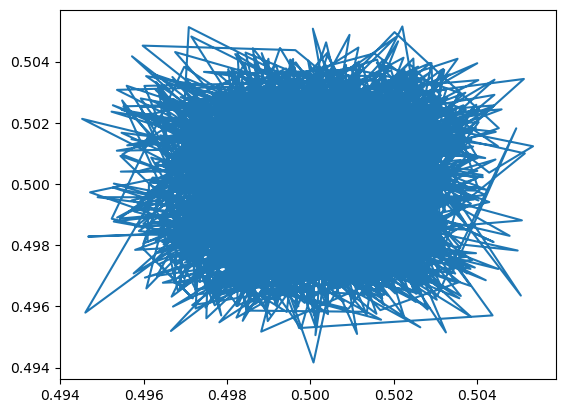

In [ ]:
x = np.load("../aezip/data.npy").reshape(2501,-1, 3)
print(x.shape)
import matplotlib.pyplot as plt
plt.plot(x[0, :, 0], x[0, :, 1])
plt.show()




In [5]:
import argparse
import mdtraj as md
from aezip.trajectory_backmapping import trajectory_reconstruction
from aezip.config.config import cartesian_definitions
from aezip.prep.featurize import get_protonation_states
args = argparse.Namespace()
args.output_pdb = "./recon_traj.pdb"
args.output_file = "./recon_traj.xtc"

traj = md.load("../aezip/test/ref/trajs/WT_apo_chA.xtc", 
               top="../aezip/test/ref/top/WT_apo_chA.pdb", stride=100)
reference_pdb = "../aezip/test/ref/top/WT_apo_chA.pdb"
protonation_states = get_protonation_states(traj)

cart_sel = " or ".join(
        f"(resname {res} and ({' or '.join(f'name {a}' for a in atoms)}))"
        for res, atoms in cartesian_definitions.items()
    )
partial_traj = traj.atom_slice(traj.topology.select(cart_sel))
print(partial_traj.xyz.shape)

recon_traj = trajectory_reconstruction(
            traj=partial_traj[0:3],
            output_pdb_file=args.output_pdb,
            output_xtc_file=args.output_file,
            reference_pdb=reference_pdb,
            protonation_states=protonation_states,
        )

protonation_states:  {0: 'GLN', 1: 'GLN', 2: 'GLN', 3: 'GLN', 10: 'ASP', 14: 'GLU', 15: 'HID', 20: 'ASP', 22: 'ASP', 24: 'GLU', 29: 'ARG', 42: 'ARG', 45: 'GLU', 46: 'ARG', 48: 'LYS', 49: 'GLU', 52: 'LYS', 59: 'ARG', 64: 'HIE', 67: 'HIE', 68: 'GLU', 70: 'HIE', 72: 'GLU', 78: 'ARG', 79: 'GLU', 82: 'GLU', 92: 'ARG', 99: 'ASP', 101: 'LYS', 104: 'GLU', 106: 'ARG', 111: 'GLN', 115: 'GLU', 117: 'GLU', 119: 'GLU', 122: 'LYS', 125: 'GLN', 131: 'ASP', 135: 'ARG', 137: 'ARG', 146: 'ASP', 152: 'ARG', 159: 'ARG', 163: 'ASP', 164: 'ASP', 172: 'GLN', 173: 'LYS', 177: 'GLU', 182: 'GLN', 184: 'GLU', 192: 'ARG', 193: 'LYS', 201: 'GLN', 203: 'ASP', 209: 'GLU', 210: 'GLN', 211: 'ASP', 213: 'ARG', 214: 'ASP', 216: 'ARG', 220: 'GLU', 221: 'HID', 224: 'ASP', 232: 'ARG', 233: 'LYS', 236: 'ASP', 241: 'ARG', 247: 'GLU', 249: 'HID', 252: 'LYS', 256: 'LYS', 258: 'GLU', 260: 'HIE', 261: 'GLU', 264: 'LYS', 265: 'ARG', 267: 'ASP', 268: 'GLU', 271: 'GLU', 274: 'ASP', 280: 'ARG', 282: 'ASP', 286: 'GLU', 290: 'GLU', 29

In [3]:
import json
import numpy as np
import mdtraj as md
from biobb_pytorch.mdae.mdfeaturizer import MDFeaturizer
from aezip.config.config import dihedral_definitions
from aezip.prep.featurize import (
    build_topology_dict, build_reslib_dict, 
    convert_full_to_sliced_indices, build_dihedral_atom_indices,
    build_dih_traj, get_histidine_protonation_states,
)
from aezip.utils.modelling import reconstruct_trajectory
from aezip.utils.residue_lib_manager import ResidueLib

# ── data paths ──────────────────────────────────────────────────────────────
traj_path = "../aezip/test/ref/trajs/WT_apo_chA.xtc"
top_path  = "../aezip/test/ref/top/WT_apo_chA.pdb"

res_library = ResidueLib("../aezip/dat/all_residues.in")
datlib_dict = json.load(open("../aezip/dat/data_lib.json"))["data_library"]["residue_data"]
reslib_dict = build_reslib_dict(res_library)

# ── load trajectory and topology ────────────────────────────────────────────
traj          = md.load(traj_path, top=top_path, stride=10)
topology      = md.load(top_path)
topology_dict = build_topology_dict(topology)
hist_dict     = get_histidine_protonation_states(topology)

# ── featurize ────────────────────────────────────────────────────────────────
# Backbone cartesian (N, CA, C; include PRO for ring atoms)
backbone_sel     = "name N or name CA or name C or resname PRO"
backbone_indices = traj.topology.select(backbone_sel)
sliced_traj      = traj.atom_slice(backbone_indices)
backbone_top     = sliced_traj.topology

coord_feat = sliced_traj.xyz.reshape(len(sliced_traj), -1)   # (n_frames, n_backbone*3)

# Custom dihedrals — only those defined in aa_dih.json (not all sidechain dihedrals)
dihedral_indices_and_names = get_dihedral_indices_and_names(traj, dihedral_definitions)
dih_feat = calculate_dih_traj(traj, dihedral_indices_and_names)   # (n_frames, n_dihedrals)

raw_feat = np.concatenate((coord_feat, dih_feat), axis=1)
print(f"Feature array shape : {raw_feat.shape}")
print(f"  backbone coords   : {coord_feat.shape[1]}")
print(f"  custom dihedrals  : {dih_feat.shape[1]}")

# ── split back for reconstruction ────────────────────────────────────────────
n_backbone   = sliced_traj.n_atoms
backbone_xyz = raw_feat[:, : n_backbone * 3]
dih_raw      = raw_feat[:, n_backbone * 3 :]

sliced_top_traj = md.Trajectory(
    np.zeros((1, backbone_top.n_atoms, 3)),
    topology=backbone_top,
)
sliced_indices = convert_full_to_sliced_indices(topology, sliced_top_traj)

sliced_traj_recon = md.Trajectory(
    backbone_xyz.reshape(len(raw_feat), -1, 3),
    topology=backbone_top,
)

dihedral_mapping = build_dihedral_atom_indices(topology, dihedral_definitions)
dihedral_traj    = build_dih_traj(dih_raw, dihedral_mapping)

# ── reconstruct all-atom trajectory (test on first 3 frames) ─────────────────
recon_xyz = reconstruct_trajectory(
    topology, sliced_traj_recon[0:3], sliced_indices,
    dihedral_traj, dihedral_definitions,
    topology_dict, reslib_dict, datlib_dict, hist_dict,
)
recon_traj = md.Trajectory(recon_xyz / 10, topology=topology.topology)
print(f"Reconstructed trajectory shape: {recon_traj.xyz.shape}")
recon_traj.save_xtc("./recon_traj_dihedral.xtc")


2026-03-31 18:56:45,679 [MainThread  ] [INFO ]  ## BioBB Featurization - MDFeaturizer ##
2026-03-31 18:56:45,680 [MainThread  ] [INFO ]  Obtaining the topology information from ../aezip/test/ref/top/WT_apo_chA.pdb


/home/pzanders/miniconda3/envs/aezip_env/lib/python3.12/site-packages/biobb_common/tools/file_utils.py:814: UserWarning: biobb_pytorch.mdae.mdfeaturizer output_dataset_pt_path: None has no extension. If you want to suppress this message, please set the check_extensions property to False
  warnings.warn(no_extension_error_string)
/home/pzanders/miniconda3/envs/aezip_env/lib/python3.12/site-packages/biobb_common/tools/file_utils.py:814: UserWarning: biobb_pytorch.mdae.mdfeaturizer output_stats_pt_path: None has no extension. If you want to suppress this message, please set the check_extensions property to False
  warnings.warn(no_extension_error_string)


2026-03-31 18:56:45,979 [MainThread  ] [INFO ]  Available Topology Properties:
2026-03-31 18:56:45,980 [MainThread  ] [INFO ]    - Number of chains: 1
2026-03-31 18:56:45,980 [MainThread  ] [INFO ]    - Number of residues: 517
2026-03-31 18:56:45,980 [MainThread  ] [INFO ]    - Number of atoms: 1551
2026-03-31 18:56:45,981 [MainThread  ] [INFO ]    - Number of distances: N/A
2026-03-31 18:56:45,981 [MainThread  ] [INFO ]    - Number of angles: N/A
2026-03-31 18:56:45,981 [MainThread  ] [INFO ]    - Number of dihedrals: 13882
2026-03-31 18:56:53,664 [MainThread  ] [INFO ]  Available Trajectory Properties:
2026-03-31 18:56:53,665 [MainThread  ] [INFO ]     - Number of frames: 25001
2026-03-31 18:56:53,665 [MainThread  ] [INFO ]  Featurizing the trajectory ../aezip/test/ref/trajs/WT_apo_chA.xtc


: 

In [4]:
from biobb_pytorch.mdae.mdfeaturizer import MDFeaturizer
from aezip.config.config import cartesian_definitions

cart_sel = " or ".join(
        f"(resname {res} and ({' or '.join(f'name {a}' for a in atoms)}))"
        for res, atoms in cartesian_definitions.items()
    )
feat = MDFeaturizer(
    input_topology_path="../aezip/test/ref/top/WT_apo_chA.pdb",
    input_trajectory_path="../aezip/test/ref/trajs/WT_apo_chA.xtc",
    output_stats_pt_path=None,
    output_dataset_pt_path=None,
    properties={"cartesian": {"selection": cart_sel}}
)

print(feat.stats.keys())

2026-03-30 21:58:22,935 [MainThread  ] [INFO ]  ## BioBB Featurization - MDFeaturizer ##
2026-03-30 21:58:22,936 [MainThread  ] [INFO ]  Obtaining the topology information from ../aezip/test/ref/top/WT_apo_chA.pdb


/home/pzanders/miniconda3/envs/aezip_env/lib/python3.12/site-packages/biobb_common/tools/file_utils.py:814: UserWarning: biobb_pytorch.mdae.mdfeaturizer output_dataset_pt_path: None has no extension. If you want to suppress this message, please set the check_extensions property to False
  warnings.warn(no_extension_error_string)
/home/pzanders/miniconda3/envs/aezip_env/lib/python3.12/site-packages/biobb_common/tools/file_utils.py:814: UserWarning: biobb_pytorch.mdae.mdfeaturizer output_stats_pt_path: None has no extension. If you want to suppress this message, please set the check_extensions property to False
  warnings.warn(no_extension_error_string)


2026-03-30 21:58:25,290 [MainThread  ] [INFO ]  Available Topology Properties:
2026-03-30 21:58:25,291 [MainThread  ] [INFO ]    - Number of chains: 1
2026-03-30 21:58:25,291 [MainThread  ] [INFO ]    - Number of residues: 517
2026-03-30 21:58:25,291 [MainThread  ] [INFO ]    - Number of atoms: 2413
2026-03-30 21:58:25,292 [MainThread  ] [INFO ]    - Number of distances: N/A
2026-03-30 21:58:25,292 [MainThread  ] [INFO ]    - Number of angles: N/A
2026-03-30 21:58:25,292 [MainThread  ] [INFO ]    - Number of dihedrals: N/A
2026-03-30 21:58:39,618 [MainThread  ] [INFO ]  Available Trajectory Properties:
2026-03-30 21:58:39,619 [MainThread  ] [INFO ]     - Number of frames: 25001
2026-03-30 21:58:39,620 [MainThread  ] [INFO ]  Featurizing the trajectory ../aezip/test/ref/trajs/WT_apo_chA.xtc
2026-03-30 21:58:50,432 [MainThread  ] [INFO ]  Features:
2026-03-30 21:58:50,443 [MainThread  ] [INFO ]    Cartesian:
2026-03-30 21:58:50,443 [MainThread  ] [INFO ]     - Topology Selection: (resnam

In [ ]:
from biobb_pytorch.mdae.mdfeaturizer import MDFeaturizer
from aezip.config.config import cartesian_definitions

cart_sel = " or ".join(
        f"(resname {res} and ({' or '.join(f'name {a}' for a in atoms)}))"
        for res, atoms in cartesian_definitions.items()
    )
feat = MDFeaturizer(
    input_topology_path="../aezip/test/ref/top/WT_apo_chA.pdb",
    input_trajectory_path="../aezip/test/ref/trajs/WT_apo_chA.xtc",
    output_stats_pt_path=None,
    output_dataset_pt_path=None,
    properties={"cartesian": {"selection": cart_sel}}
)

print(feat.stats.keys())
dict_keys(['mean', 'std', 'min', 'max', 'shape', 'selection', 'topology', 'parametric', 'cartesian_indices', 'distance_indices', 'angle_indices', 'dihedral_indices'])

from biobb_pytorch.mdae.build_model import BuildModel

properties = {
    "model_type": "AutoEncoder",
    "n_cvs": 3,
    "encoder_layers": [512, 256, 128, 64, 32],
    "decoder_layers": [32, 64, 128, 256, 512],
    "options": {
        "encoder": {"activation": "relu", "last_layer_activation": False},
        "decoder": {"activation": "relu", "last_layer_activation": "sigmoid"},
        "optimizer": {"lr": 5e-5},
        
        "loss_function": {
            "loss_type": "MSELoss",
            }
    }
}

model = BuildModel(input_stats=feat.stats,
                    output_model_pth_path=None,
                    properties=properties)

from biobb_pytorch.mdae.train_model import TrainModel

properties = {
    'Dataset': {
        'batch_size': 16,
        'shuffle': True,
        'split': {'random_split': True,
                  'train_prop': 0.9,
                  'val_prop': 0.1,

        },
    },
    'Trainer': {
        'max_epochs': 1,
        'enable_checkpointing': False,
        'callbacks': {},
        
    },
    'disable_sandbox': True
}

tm = TrainModel(
                input_model=model.model,
                input_dataset=feat.dataset,
                properties=properties
                )
tm.run_training()

from biobb_pytorch.mdae.evaluate_model import EvaluateModel

properties = {
    'Dataset': {
        'batch_size': 12
    }
}

em = EvaluateModel(
    input_model=model.model,
    input_dataset=feat.dataset,
    properties=properties
)
eval_results = em.run_evaluation()

from biobb_pytorch.mdae.decode_model import EvaluateDecoder, decode_model

properties = {
    'Dataset': {
        'batch_size': 12
    }
}

ed = EvaluateDecoder(
    input_model=model.model,
    input_latent=eval_results["z"],
    properties=properties
)
dec_results = ed.run_decoding()


2026-03-30 21:58:50,465 [MainThread  ] [INFO ]  ## BioBB Featurization - MDFeaturizer ##
2026-03-30 21:58:50,466 [MainThread  ] [INFO ]  Obtaining the topology information from ../aezip/test/ref/top/WT_apo_chA.pdb
2026-03-30 21:58:53,168 [MainThread  ] [INFO ]  Available Topology Properties:
2026-03-30 21:58:53,168 [MainThread  ] [INFO ]    - Number of chains: 1
2026-03-30 21:58:53,169 [MainThread  ] [INFO ]    - Number of residues: 517
2026-03-30 21:58:53,169 [MainThread  ] [INFO ]    - Number of atoms: 2413
2026-03-30 21:58:53,169 [MainThread  ] [INFO ]    - Number of distances: N/A
2026-03-30 21:58:53,170 [MainThread  ] [INFO ]    - Number of angles: N/A
2026-03-30 21:58:53,170 [MainThread  ] [INFO ]    - Number of dihedrals: N/A
2026-03-30 21:59:19,323 [MainThread  ] [INFO ]  Available Trajectory Properties:
2026-03-30 21:59:19,329 [MainThread  ] [INFO ]     - Number of frames: 25001
2026-03-30 21:59:19,329 [MainThread  ] [INFO ]  Featurizing the trajectory ../aezip/test/ref/trajs/

TypeError: BuildModel.__init__() missing 1 required positional argument: 'input_stats_pt_path'